<a href="https://colab.research.google.com/github/atikaakhtar101110-debug/NLP_DL/blob/main/nlp_deep_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
%matplotlib inline
from datasets import load_dataset


In [ ]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text = emotion_dataset['train']['text']
train_label = emotion_dataset['train']['label']
test_text = emotion_dataset['test']['text']
test_label = emotion_dataset['test']['label']

In [ ]:
label_names = emotion_dataset['train'].features['label'].names

In [ ]:
for i in train_label:
  print(label_names[i])

Streaming output truncated to the last 5000 lines.
sadness
sadness
anger
fear
love
joy
anger
sadness
sadness
joy
fear
joy
fear
love
love
anger
anger
sadness
fear
sadness
sadness
surprise
love
joy
joy
love
sadness
joy
joy
fear
sadness
anger
anger
sadness
love
fear
fear
anger
anger
joy
sadness
sadness
joy
joy
fear
sadness
joy
love
fear
anger
sadness
joy
anger
surprise
fear
joy
joy
love
fear
sadness
joy
anger
fear
anger
sadness
sadness
sadness
anger
sadness
fear
joy
anger
anger
sadness
fear
joy
anger
fear
sadness
joy
fear
joy
love
anger
fear
fear
fear
fear
joy
anger
anger
sadness
joy
sadness
joy
sadness
sadness
joy
sadness
fear
fear
joy
sadness
joy
sadness
joy
fear
anger
sadness
joy
anger
joy
joy
sadness
joy
joy
anger
anger
joy
joy
joy
sadness
joy
joy
joy
anger
anger
joy
love
joy
love
joy
joy
joy
sadness
joy
sadness
surprise
sadness
anger
anger
anger
fear
fear
joy
fear
fear
joy
anger
joy
joy
joy
love
joy
fear
sadness
sadness
surprise
sadness
sadness
anger
joy
love
fear
joy
anger
joy
surpr

In [ ]:
df_train = pd.DataFrame({
    'text': train_text,
    'label': [label_names[i] for i in train_label]
})
df_test = pd.DataFrame({
    'text': test_text,
    'label': [label_names[i] for i in test_label]
})

In [ ]:
df_train['label'].value_counts()

,count
label,
joy,5362
sadness,4666
anger,2159
fear,1937
love,1304
surprise,572


<Axes: xlabel='label', ylabel='count'>

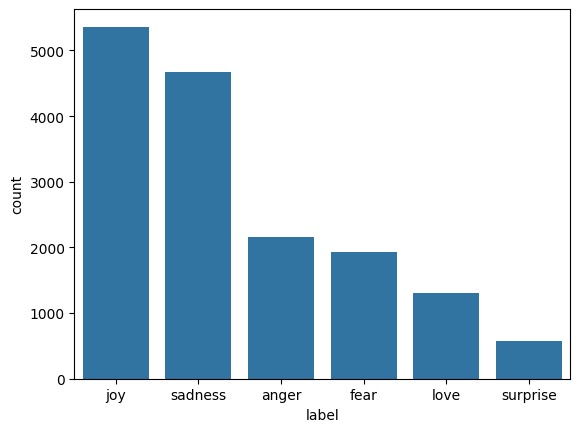

In [ ]:
sns.countplot(x = 'label', data = df_train, order = df_train['label'].value_counts().index)

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical

max_words = 10000
tokenizer = Tokenizer(num_words = max_words, oov_token = '<unk>')
tokenizer.fit_on_texts(df_train['text'])
train_squence = tokenizer.texts_to_sequences(df_train['text'])
#train_squence
test_squence = tokenizer.texts_to_sequences(df_test['text'])
padded_train_squence = pad_sequences(train_squence, maxlen = 50, padding='post', truncating='post')
padded_test_squence = pad_sequences(test_squence, maxlen = 50, padding='post', truncating='post')
train_labels = np.array(train_label)
test_labels = np.array(test_label)
train_labels


array([0, 0, 3, ..., 1, 3, 0])

In [ ]:
num_classes = len(np.unique(train_labels))
#num_classes
print(f"vocablary size: {len(tokenizer.word_index)}")
print(f"max sentence length: {padded_train_squence.shape[1]}")
#

vocablary size: 15213
max sentence length: 50


In [ ]:
from sklearn.utils import class_weight
class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y = train_labels
)
#class_weights
class_weigh_dict = dict(enumerate(class_weights))

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor = 'val_loss',
                           patience = 3,
                           verbose = 1,
                           restore_best_weights = True
                           )

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Dense, SimpleRNN, Dropout, LSTM, GRU
rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [ ]:
from sklearn.utils import class_weight
import numpy as np

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_labels),
    y = train_labels
)
class_weigh_dict = dict(enumerate(class_weights))

rnn_model.fit(
    padded_train_squence,
    train_labels,
    validation_data = (padded_test_squence, test_labels),
    epochs = 20,
    batch_size = 32,
    validation_split = 0.2,
    class_weight = class_weigh_dict,
    callbacks = [early_stop]

)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 45s 68ms/step - accuracy: 0.1626 - loss: 1.9714 - val_accuracy: 0.0475 - val_loss: 1.9181
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 34s 68ms/step - accuracy: 0.1514 - loss: 1.8888 - val_accuracy: 0.0480 - val_loss: 1.8302
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - accuracy: 0.1402 - loss: 1.8264 - val_accuracy: 0.0325 - val_loss: 1.8039
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 73s 68ms/step - accuracy: 0.1308 - loss: 1.8028 - val_accuracy: 0.0365 - val_loss: 1.7796
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 44s 74ms/step - accuracy: 0.1427 - loss: 1.8012 - val_accuracy: 0.3225 - val_loss: 1.7242
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 33s 66ms/step - accuracy: 0.1418 - loss: 1.8032 - val_accuracy: 0.0480 - val_loss: 1.8198
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 41s 65ms/step - accuracy: 0.1388 - loss: 1.8021 - val_accuracy: 0.1190 - val_loss: 1.8064
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 61ms/step - accuracy: 0.1419 - loss: 1.8035 - 

In [ ]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_squence,
    train_labels,
    validation_data=(padded_test_squence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight = class_weigh_dict,
    callbacks=[early_stop]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_squence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 91s 169ms/step - accuracy: 0.1657 - loss: 1.7948 - val_accuracy: 0.2810 - val_loss: 1.7830
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 88s 176ms/step - accuracy: 0.1634 - loss: 1.7934 - val_accuracy: 0.1360 - val_loss: 1.7958
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 134s 159ms/step - accuracy: 0.1502 - loss: 1.7930 - val_accuracy: 0.1325 - val_loss: 1.7877
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step - accuracy: 0.2810 - loss: 1.7830
LSTM Loss: 1.7829819917678833
LSTM Accuracy: 0.2809999883174896


In [ ]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_squence,
    train_labels,
    validation_data=(padded_test_squence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weigh_dict,
    callbacks=[early_stop]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_squence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 86s 165ms/step - accuracy: 0.1486 - loss: 1.7981 - val_accuracy: 0.0350 - val_loss: 1.8044
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 133s 146ms/step - accuracy: 0.1540 - loss: 1.7952 - val_accuracy: 0.2880 - val_loss: 1.7912
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 73s 129ms/step - accuracy: 0.1539 - loss: 1.7942 - val_accuracy: 0.0840 - val_loss: 1.7767
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.0350 - loss: 1.8044
GRU Loss: 1.8044246435165405
GRU Accuracy: 0.03500000014901161


In [ ]:
rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_squence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.3225 - loss: 1.7242
RNN Loss: 1.7241911888122559
RNN Accuracy: 0.32249999046325684


,Model,Test Loss,Test Accuracy
0,RNN,1.724191,0.3225
1,LSTM,1.782982,0.2810
2,GRU,1.804425,0.0350


In [ ]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_13 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_26 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_27 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BiGRU.fit(
    padded_train_squence,
    train_labels,
    validation_data=(padded_test_squence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight = class_weigh_dict,
    callbacks=[early_stop]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 195s 376ms/step - accuracy: 0.6083 - loss: 1.0034 - val_accuracy: 0.8945 - val_loss: 0.3362
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 183s 366ms/step - accuracy: 0.9238 - loss: 0.2171 - val_accuracy: 0.9205 - val_loss: 0.2333
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 205s 372ms/step - accuracy: 0.9491 - loss: 0.1435 - val_accuracy: 0.9220 - val_loss: 0.2394
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 181s 362ms/step - accuracy: 0.9609 - loss: 0.1060 - val_accuracy: 0.9180 - val_loss: 0.2229
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 179s 358ms/step - accuracy: 0.9697 - loss: 0.0818 - val_accuracy: 0.9215 - val_loss: 0.2747
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 237s 474ms/step - accuracy: 0.9757 - loss: 0.0706 - val_accuracy: 0.9305 - val_loss: 0.2442
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 214s 378ms/step - accuracy: 0.9807 - loss: 0.0580 - val_accuracy: 0.9275 - val_loss: 0.2596
Epoch 7: early stopping
Restoring model weights from the end of the best epo

In [ ]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: joy
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


In [ ]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)